# Dissertation Walkthrough — Probabilistic DRL for Portfolio Risk Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TheFinix13/Dissertation_Sample_Project/blob/main/Dissertation_Walkthrough.ipynb)

**Author:** Fiyin Akano · **Module:** EEEM004 · **Project:** *Probabilistic Deep Reinforcement Learning for Portfolio Risk Analysis: an uncertainty-aware policy for capital preservation under regime stress.*

> **Easiest way to run this:** click the **Open in Colab** badge above, then *Runtime → Run all*. The first cell automatically clones the project repository and installs everything needed; you do not need to download or check out anything yourself.

This notebook is the **single, runnable entry point** for the supervisor. It:

1. Loads and **shows the dataset** used (SPY daily adjusted close).
2. Builds the **DeepAR-style probabilistic forecaster** and shows the **uncertainty values** it produces.
3. States the **mathematics** that differentiates the **probabilistic agent from the baseline PPO** (with LaTeX equations and side-by-side diffs).
4. Runs the agents (or loads cached results), shows the **metrics table**, and plots the **equity curves**.

> Run order: top to bottom. Cells are CPU-friendly. Existing seeded results in `experiments/results/` are reused if present, so the supervisor does **not** need to retrain to see the comparison.

---

## Project objectives (recap)

- **O1.** Inject explicit forecast uncertainty (DeepAR-style probabilistic LSTM) into a PPO policy.
- **O2.** Preserve at least **95%** of high-watermark portfolio value across the test window (including shock periods).
- **O3.** Establish a reproducible evaluation protocol (fixed splits, seeds, metrics).
- **O4.** Recommend when an uncertainty signal helps — and when it does not.

## How to run this (supervisor quick start)

**Option A — Google Colab (recommended; nothing to install).**
Click the **Open in Colab** badge at the top of this notebook, then *Runtime → Run all*. The very first cell will clone the public project repository (`TheFinix13/Dissertation_Sample_Project`) into the Colab session and install everything from `requirements.txt`. You do not need a GitHub account or any local setup.

**Option B — Local Jupyter.**

```bash
git clone https://github.com/TheFinix13/Dissertation_Sample_Project.git
cd Dissertation_Sample_Project
python3 -m venv venv && source venv/bin/activate
pip install -r requirements.txt
pip install jupyter
jupyter notebook Dissertation_Walkthrough.ipynb
```

Then click **Cell → Run All**.

In either case the notebook will:

1. Pull SPY daily prices via `yfinance` for the test window in the protocol.
2. Train the small probabilistic LSTM in-place (under a minute on CPU).
3. **Reuse cached PPO results** from `experiments/results/` if present (so you do not retrain).
4. Render tables and plots.

If you want a fully fresh run, set `RERUN_AGENTS = True` in the *“Run / load agent results”* section below.

In [ ]:
"""Bootstrap cell — makes the notebook self-contained.

If the dissertation source code (the `experiments/` folder) is not already
visible from the current working directory, this cell will:

  1. `git clone` the public repository (TheFinix13/Dissertation_Sample_Project),
  2. `cd` into the cloned folder,
  3. `pip install -r requirements.txt` if any of the runtime packages are missing.

This is what lets the supervisor open the notebook in Colab and just hit
Run All without checking the repo out manually.
"""

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/TheFinix13/Dissertation_Sample_Project.git"
REPO_DIR = "Dissertation_Sample_Project"


def _have_source_here(p: Path) -> bool:
    return (p / "experiments" / "common.py").exists()


def _ensure_repo() -> Path:
    cwd = Path.cwd()
    if _have_source_here(cwd):
        return cwd
    candidate = cwd / REPO_DIR
    if _have_source_here(candidate):
        os.chdir(candidate)
        return candidate
    print(f"Cloning {REPO_URL} into {candidate} ...")
    subprocess.check_call(
        ["git", "clone", "--depth", "1", REPO_URL, str(candidate)]
    )
    os.chdir(candidate)
    return candidate


def _ensure_dependencies() -> None:
    try:
        import gymnasium  # noqa: F401
        import stable_baselines3  # noqa: F401
        import torch  # noqa: F401
        import yfinance  # noqa: F401
        return
    except ImportError:
        pass
    print("Installing runtime dependencies from requirements.txt ...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", "-r", "requirements.txt"]
    )


REPO_ROOT = _ensure_repo()
_ensure_dependencies()
print("Repository root:", REPO_ROOT)
print("Source available:", (REPO_ROOT / "experiments" / "common.py").exists())

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
EXPERIMENTS = ROOT / "experiments"
RESULTS = EXPERIMENTS / "results"
sys.path.insert(0, str(EXPERIMENTS))

from common import (
    EnvConfig,
    StockEnv,
    compute_metrics,
    fetch_close_frame,
    load_protocol,
    set_global_seed,
)

PROTOCOL = load_protocol(EXPERIMENTS / "configs" / "dissertation_protocol.json")
print("Protocol:", PROTOCOL["project"])
print("Test window:", PROTOCOL["splits"]["test"])
print("Tickers:", PROTOCOL["data"]["tickers"])
print("Seeds:", PROTOCOL["seeds"])
print("Objective:", PROTOCOL["objective"])

Protocol: Probabilistic Deep Reinforcement Learning for Portfolio Risk Analysis
Test window: ['2022-01-01', '2025-12-31']
Tickers: ['SPY', 'QQQ']
Seeds: [7, 19, 42]
Objective: Preserve at least 95% of high-watermark portfolio value during severe drawdowns.


## 1. Dataset — what we use, where it comes from, and what it looks like

- **Source.** Yahoo Finance via `yfinance` (`auto_adjust=True`, daily close).
- **Universe (Phase 1).** `SPY` (S&P 500 ETF) as the headline asset; `QQQ` is queued for robustness.
- **Splits (per protocol).**
  - **Train:** `2009-01-01 → 2018-12-31`
  - **Validation:** `2019-01-01 → 2021-12-31`
  - **Test (used in this notebook):** `2022-01-01 → 2025-12-31`
- **Pre-defined shock windows** (for stress evaluation in Phase 2):
  - COVID crash (`2020-02 → 2020-06`)
  - Ukraine-war onset (`2022-02 → 2022-09`)

Below we **physically download and display** the test-window dataset.

In [2]:
test_start, test_end = PROTOCOL["splits"]["test"]
ticker = PROTOCOL["data"]["tickers"][0]

price_df = fetch_close_frame(ticker, test_start, test_end)

close = price_df["Close"]
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]
close = close.astype("float32").rename(ticker)

print(f"{ticker}: {len(close)} trading days from {close.index[0].date()} to {close.index[-1].date()}")
display(close.head().to_frame().assign(date=close.head().index.strftime("%Y-%m-%d")).set_index("date"))
display(close.tail().to_frame().assign(date=close.tail().index.strftime("%Y-%m-%d")).set_index("date"))

print("\nDescriptive stats (USD close):")
display(close.describe().to_frame())

SPY: 1002 trading days from 2022-01-03 to 2025-12-30


,SPY
date,
2022-01-03,450.644440
2022-01-04,450.493469
2022-01-05,441.843079
2022-01-06,441.428040
2022-01-07,439.682770


,SPY
date,
2025-12-23,686.086304
2025-12-24,688.499695
2025-12-26,688.429871
2025-12-29,685.976562
2025-12-30,685.138916



Descriptive stats (USD close):


,SPY
count,1002.000000
mean,485.877014
std,97.670715
min,340.252899
25%,397.326492
50%,461.076340
75%,569.292892
max,688.499695


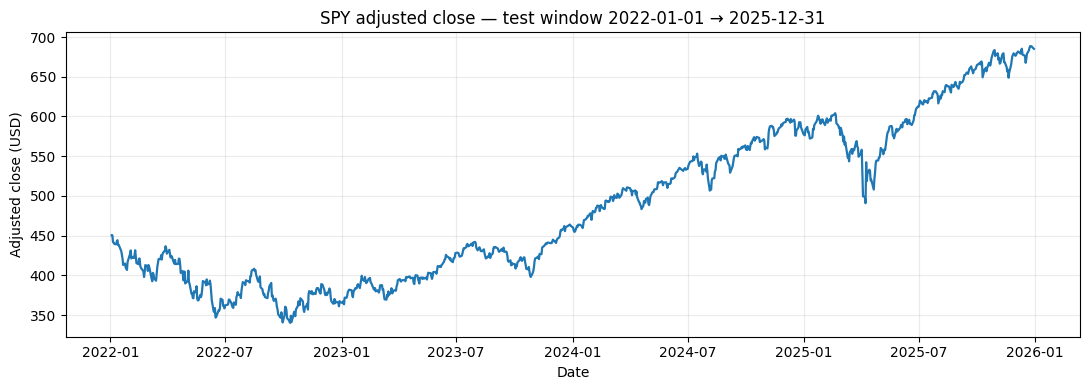

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(close.index, close.values, color="#1f77b4", lw=1.6)
ax.set_title(f"{ticker} adjusted close — test window {test_start} → {test_end}")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted close (USD)")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## 2. From prices to log-returns (data preparation)

The forecaster and the trading environment both consume **log-returns**, not raw prices.

For a price series $p_1, p_2, \dots, p_T$ we define
$$
r_t \;=\; \log p_{t} - \log p_{t-1} \;=\; \log\!\left(\frac{p_{t}}{p_{t-1}}\right), \qquad t = 2,\dots,T.
$$

Log-returns are approximately additive over time and stabilise the variance of the input. We then build supervised sequences of length $L = 20$:
$$
\mathbf{x}^{(i)} = (r_{i-L+1}, \dots, r_{i}), \qquad y^{(i)} = r_{i+1}.
$$

The next code cell builds these returns and the supervised tensors used to train the probabilistic forecaster.

In [4]:
prices = close.to_numpy(dtype="float32")
log_returns = np.diff(np.log(np.maximum(prices, 1e-8))).astype(np.float32)

print(f"Number of daily log-returns: {len(log_returns)}")
print(f"Mean: {log_returns.mean():+.6f}    Std: {log_returns.std():+.6f}")
print(f"Min:  {log_returns.min():+.6f}    Max: {log_returns.max():+.6f}")

ret_df = pd.DataFrame(
    {"date": close.index[1:].strftime("%Y-%m-%d"),
     "price": prices[1:],
     "log_return": log_returns}
).set_index("date")
display(ret_df.head())
display(ret_df.tail())

Number of daily log-returns: 1001
Mean: +0.000419    Std: +0.011323
Min:  -0.060327    Max: +0.099863


,price,log_return
date,,
2022-01-04,450.493469,-0.000335
2022-01-05,441.843079,-0.019389
2022-01-06,441.428040,-0.000940
2022-01-07,439.682770,-0.003962
2022-01-10,439.135620,-0.001245


,price,log_return
date,,
2025-12-23,686.086304,0.004560
2025-12-24,688.499695,0.003511
2025-12-26,688.429871,-0.000102
2025-12-29,685.976562,-0.003570
2025-12-30,685.138916,-0.001222


## 3. Probabilistic forecaster — DeepAR-style LSTM

The forecaster reads the last $L$ log-returns and emits a **distribution** for the next return, not a point estimate.

### Architecture
$$
\mathbf{h}_t = \operatorname{LSTM}(\mathbf{x}_{1:t}; \theta), \qquad
\mu_t = W_\mu \mathbf{h}_t + b_\mu, \qquad
\log\sigma^2_t = W_\sigma \mathbf{h}_t + b_\sigma.
$$
The model parameters $\theta$ contain the LSTM weights and the two output heads $W_\mu, b_\mu, W_\sigma, b_\sigma$.

### Loss (Gaussian negative log-likelihood)
Given a target $y_t = r_{t+1}$, the network is trained to minimise
$$
\mathcal{L}(\theta) \;=\; \frac{1}{N}\sum_{t} \frac{1}{2}\!\left[\,\log\!\big(\sigma^2_t + \varepsilon\big) \;+\; \frac{(y_t - \mu_t)^2}{\sigma^2_t + \varepsilon}\,\right],
\qquad \sigma^2_t = \exp(\log\sigma^2_t).
$$
The first term penalises overconfidence, the second penalises mis-prediction; together they push the network to **calibrate its variance**.

### Uncertainty score
We turn the predictive standard deviation into a normalised uncertainty score $u_t \in [0, 1]$:
$$
\hat\sigma_t = \sqrt{\sigma^2_t}, \qquad
u_t = \frac{\hat\sigma_t - \min_t \hat\sigma_t}{\max_t \hat\sigma_t - \min_t \hat\sigma_t + 10^{-8}}.
$$
$u_t$ is what the trading environment consumes.

The next cell trains a small LSTM (≈1k params) for a few epochs, then **prints concrete uncertainty values** and plots them next to price.

In [5]:
from run_probabilistic_agent import estimate_uncertainty

set_global_seed(7)
uncertainty = estimate_uncertainty(prices, seq_len=20, epochs=20)
threshold = float(np.quantile(uncertainty, PROTOCOL["probabilistic_agent"]["uncertainty_quantile_stop"]))

print(f"Uncertainty array length: {len(uncertainty)} (matches len(prices) = {len(prices)})")
print(f"min={uncertainty.min():.4f}  mean={uncertainty.mean():.4f}  max={uncertainty.max():.4f}")
print(f"80th-percentile threshold (used as the 'block buys' guard): {threshold:.4f}")

unc_df = pd.DataFrame(
    {"date": close.index.strftime("%Y-%m-%d"),
     "price": prices,
     "uncertainty_u_t": uncertainty,
     "above_threshold": uncertainty >= threshold}
).set_index("date")

print("\nFirst 5 days:")
display(unc_df.head())
print("Last 5 days:")
display(unc_df.tail())
print(f"\nDays in 'high-uncertainty' regime: {int(unc_df['above_threshold'].sum())} / {len(unc_df)}")

Uncertainty array length: 1002 (matches len(prices) = 1002)
min=0.0000  mean=0.7118  max=0.9999
80th-percentile threshold (used as the 'block buys' guard): 0.8070

First 5 days:


,price,uncertainty_u_t,above_threshold
date,,,
2022-01-03,450.644440,0.761258,False
2022-01-04,450.493469,0.761258,False
2022-01-05,441.843079,0.761258,False
2022-01-06,441.428040,0.761258,False
2022-01-07,439.682770,0.761258,False


Last 5 days:


,price,uncertainty_u_t,above_threshold
date,,,
2025-12-23,686.086304,0.694481,False
2025-12-24,688.499695,0.745848,False
2025-12-26,688.429871,0.782147,False
2025-12-29,685.976562,0.796530,False
2025-12-30,685.138916,0.782832,False



Days in 'high-uncertainty' regime: 201 / 1002


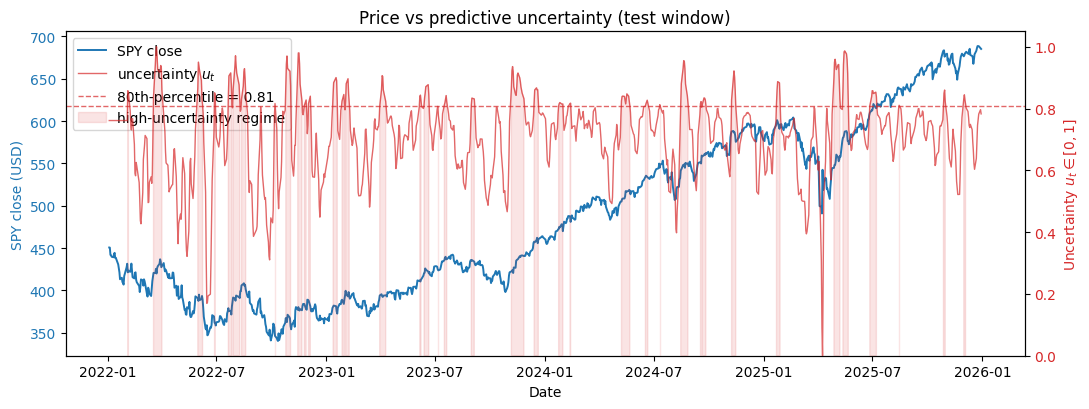

In [6]:
fig, ax_price = plt.subplots(figsize=(11, 4.2))
ax_price.plot(close.index, prices, color="#1f77b4", lw=1.4, label=f"{ticker} close")
ax_price.set_xlabel("Date")
ax_price.set_ylabel(f"{ticker} close (USD)", color="#1f77b4")
ax_price.tick_params(axis="y", labelcolor="#1f77b4")

ax_unc = ax_price.twinx()
ax_unc.plot(close.index, uncertainty, color="#d62728", lw=1.0, alpha=0.7, label="uncertainty $u_t$")
ax_unc.axhline(threshold, color="#d62728", lw=1.0, ls="--", alpha=0.7, label=f"80th-percentile = {threshold:.2f}")
ax_unc.fill_between(close.index, 0, uncertainty, where=uncertainty >= threshold,
                     color="#d62728", alpha=0.12, label="high-uncertainty regime")
ax_unc.set_ylabel("Uncertainty $u_t \\in [0,1]$", color="#d62728")
ax_unc.tick_params(axis="y", labelcolor="#d62728")
ax_unc.set_ylim(0, 1.05)

lines, labels = ax_price.get_legend_handles_labels()
lines2, labels2 = ax_unc.get_legend_handles_labels()
ax_price.legend(lines + lines2, labels + labels2, loc="upper left")
plt.title("Price vs predictive uncertainty (test window)")
plt.tight_layout()
plt.show()

## 4. Trading environment — the *only* place the two agents differ

Both agents see exactly the same market and are trained with exactly the same PPO algorithm. The **only difference** is two extra terms in the environment that the probabilistic agent uses.

Let
- $a_t \in [-1, 1]$ — raw policy action,
- $B_t$ — cash balance,
- $f_{\max} = 0.10$ — max trade fraction of cash,
- $u_t \in [0,1]$ — uncertainty signal,
- $\tau$ — uncertainty threshold (80th-percentile quantile),
- $s_{\min} = 0.10$ — minimum trade scale.

### Baseline PPO trade size
$$
v^{\text{base}}_t \;=\; B_t \cdot f_{\max} \cdot a_t.
$$

### Probabilistic PPO trade size (uncertainty-aware)
$$
\boxed{
\; v^{\text{prob}}_t \;=\; B_t \cdot f_{\max} \cdot a_t \cdot \underbrace{\max(\,1 - u_t,\; s_{\min}\,)}_{\text{trade-scaling}}, \quad
\text{and set } v^{\text{prob}}_t = 0 \text{ if } u_t \ge \tau \text{ and } v^{\text{prob}}_t > 0. \;}
$$

The two extra terms (highlighted in the box) are the **mathematical contribution of this dissertation**:

1. **Trade scaling** $\max(1 - u_t, s_{\min})$ — shrinks every trade in proportion to forecast uncertainty, with a floor.
2. **Risk-on guard** — when uncertainty exceeds $\tau$, **new buys are blocked** (the agent can still de-risk by selling).

### State
The probabilistic agent receives the uncertainty as an extra coordinate:
$$
\text{baseline:}\quad s_t = \big[\,r_{t-L+1:t},\; \text{position}_t\,\big],
\qquad
\text{probabilistic:}\quad s_t = \big[\,r_{t-L+1:t},\; \text{position}_t,\; u_t\,\big].
$$

### Reward (shared)
$$
R_t = 100 \cdot \log\!\left(\frac{V_{t+1}}{V_t}\right), \qquad V_t = B_t + n_t \cdot p_t,
$$
i.e. the log-growth of portfolio value, scaled. The same PPO algorithm (Schulman et al., 2017) optimises this reward in both cases.

### What this means in plain English
> The baseline trades freely up to 10% of cash. The probabilistic agent trades the **same way in calm regimes** but **shrinks** trades when the forecast variance rises and **stops adding new long exposure** when the forecast variance is in its top 20%. Everything else is identical.

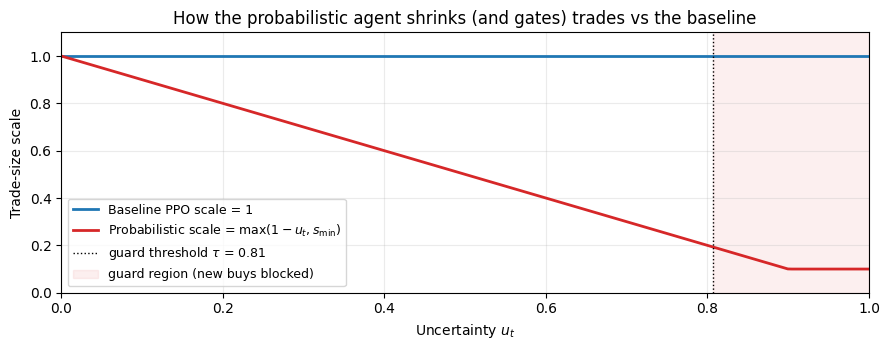

In [7]:
u_grid = np.linspace(0.0, 1.0, 200)
s_min = PROTOCOL["probabilistic_agent"]["position_scale_floor"]
trade_scale = np.maximum(1.0 - u_grid, s_min)

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(u_grid, np.ones_like(u_grid), color="#1f77b4", lw=2.0, label="Baseline PPO scale = 1")
ax.plot(u_grid, trade_scale, color="#d62728", lw=2.0, label=r"Probabilistic scale = max$(1-u_t, s_{\min})$")
ax.axvline(threshold, color="black", ls=":", lw=1.0, label=f"guard threshold $\\tau$ = {threshold:.2f}")
ax.axvspan(threshold, 1.0, color="#d62728", alpha=0.07, label="guard region (new buys blocked)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.1)
ax.set_xlabel("Uncertainty $u_t$")
ax.set_ylabel("Trade-size scale")
ax.set_title("How the probabilistic agent shrinks (and gates) trades vs the baseline")
ax.grid(True, alpha=0.25)
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Run / load agent results

By default we **load the cached seeded results** in `experiments/results/` so the supervisor immediately sees the comparison without retraining.

To retrain end-to-end (≈ a few minutes on CPU), set `RERUN_AGENTS = True` in the cell below.

In [8]:
RERUN_AGENTS = False

if RERUN_AGENTS:
    import subprocess
    for script in ["run_baseline.py", "run_probabilistic_agent.py", "run_benchmarks.py"]:
        print(f"Running experiments/{script} ...")
        result = subprocess.run(
            [sys.executable, str(EXPERIMENTS / script)],
            capture_output=True, text=True
        )
        print(result.stdout[-500:])
        if result.returncode != 0:
            print("STDERR:", result.stderr[-500:])

def latest(prefix: str) -> Path:
    files = sorted(p for p in RESULTS.glob(f"{prefix}_*.json"))
    if not files:
        raise FileNotFoundError(f"No cached {prefix}_*.json — set RERUN_AGENTS = True.")
    return files[-1]

baseline_rows = json.loads(latest("baseline").read_text())
prob_rows = json.loads(latest("probabilistic").read_text())
bench_rows = json.loads(latest("benchmarks").read_text())

print("Loaded:")
print("  baseline       ->", latest("baseline").name, f"({len(baseline_rows)} seeds)")
print("  probabilistic  ->", latest("probabilistic").name, f"({len(prob_rows)} seeds)")
print("  benchmarks     ->", latest("benchmarks").name)

Loaded:
  baseline       -> baseline_20260411T232629Z.json (3 seeds)


  probabilistic  -> probabilistic_20260411T232646Z.json (3 seeds)
  benchmarks     -> benchmarks_20260411T232702Z.json


In [9]:
def _avg(rows, key):
    return float(np.mean([float(r[key]) for r in rows]))

bench = {r["agent"]: r for r in bench_rows}

summary = pd.DataFrame([
    {
        "Agent": "Baseline PPO",
        "Final value (USD)": _avg(baseline_rows, "final_portfolio_value"),
        "Sharpe": _avg(baseline_rows, "sharpe_ratio"),
        "Max drawdown": _avg(baseline_rows, "max_drawdown"),
        "VaR-95 viol.": _avg(baseline_rows, "var_95_violation_rate"),
        "Preservation vs HWM": _avg(baseline_rows, "capital_preservation_rate_95pct_hwm"),
    },
    {
        "Agent": "Probabilistic PPO",
        "Final value (USD)": _avg(prob_rows, "final_portfolio_value"),
        "Sharpe": _avg(prob_rows, "sharpe_ratio"),
        "Max drawdown": _avg(prob_rows, "max_drawdown"),
        "VaR-95 viol.": _avg(prob_rows, "var_95_violation_rate"),
        "Preservation vs HWM": _avg(prob_rows, "capital_preservation_rate_95pct_hwm"),
    },
    {
        "Agent": "Buy-and-hold (SPY)",
        "Final value (USD)": float(bench["buy_and_hold"]["final_portfolio_value"]),
        "Sharpe": float(bench["buy_and_hold"]["sharpe_ratio"]),
        "Max drawdown": float(bench["buy_and_hold"]["max_drawdown"]),
        "VaR-95 viol.": float(bench["buy_and_hold"]["var_95_violation_rate"]),
        "Preservation vs HWM": float(bench["buy_and_hold"]["capital_preservation_rate_95pct_hwm"]),
    },
    {
        "Agent": "All-cash",
        "Final value (USD)": float(bench["all_cash"]["final_portfolio_value"]),
        "Sharpe": float(bench["all_cash"]["sharpe_ratio"]),
        "Max drawdown": float(bench["all_cash"]["max_drawdown"]),
        "VaR-95 viol.": float(bench["all_cash"]["var_95_violation_rate"]),
        "Preservation vs HWM": float(bench["all_cash"]["capital_preservation_rate_95pct_hwm"]),
    },
]).set_index("Agent")

styled = summary.style.format({
    "Final value (USD)": "${:,.0f}",
    "Sharpe": "{:+.4f}",
    "Max drawdown": "{:.4f}",
    "VaR-95 viol.": "{:.4f}",
    "Preservation vs HWM": "{:.4f}",
})
styled

,Final value (USD),Sharpe,Max drawdown,VaR-95 viol.,Preservation vs HWM
Agent,,,,,
Baseline PPO,"$985,463",-0.4285,0.0209,0.0105,0.9811
Probabilistic PPO,"$1,618,577",+0.8511,0.1833,0.0500,0.9965
Buy-and-hold (SPY),"$1,520,353",+0.5867,0.2450,0.0500,0.9951
All-cash,"$1,000,000",+0.0000,0.0000,0.0000,1.0000


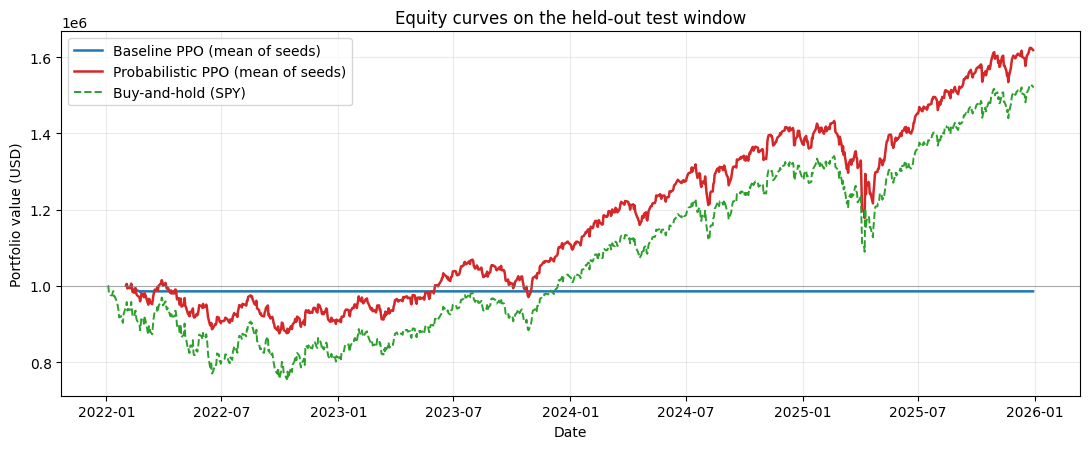

In [10]:
def _latest_curve(prefix: str) -> Path:
    files = sorted(p for p in RESULTS.glob(f"{prefix}_curve_*.csv"))
    if not files:
        raise FileNotFoundError(f"No {prefix}_curve_*.csv yet — set RERUN_AGENTS = True.")
    run_id = files[-1].name.split("_curve_")[1].split("_seed")[0]
    return run_id

baseline_run = _latest_curve("baseline")
prob_run = _latest_curve("probabilistic")

def load_curves(prefix: str, run_id: str) -> pd.DataFrame:
    frames = []
    for p in sorted(RESULTS.glob(f"{prefix}_curve_{run_id}_seed*.csv")):
        df = pd.read_csv(p, parse_dates=["date"])
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

baseline_curves = load_curves("baseline", baseline_run)
prob_curves = load_curves("probabilistic", prob_run)

baseline_mean = baseline_curves.groupby("date")["portfolio_value"].mean()
prob_mean = prob_curves.groupby("date")["portfolio_value"].mean()

initial_balance = 1_000_000.0
shares = initial_balance / max(float(prices[0]), 1e-8)
bnh_curve = pd.Series(shares * prices, index=close.index)

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(baseline_mean.index, baseline_mean.values, color="#1f77b4", lw=1.8, label="Baseline PPO (mean of seeds)")
ax.plot(prob_mean.index, prob_mean.values, color="#d62728", lw=1.8, label="Probabilistic PPO (mean of seeds)")
ax.plot(bnh_curve.index, bnh_curve.values, color="#2ca02c", lw=1.4, ls="--", label="Buy-and-hold (SPY)")
ax.axhline(initial_balance, color="grey", lw=0.8, alpha=0.6)
ax.set_title("Equity curves on the held-out test window")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio value (USD)")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

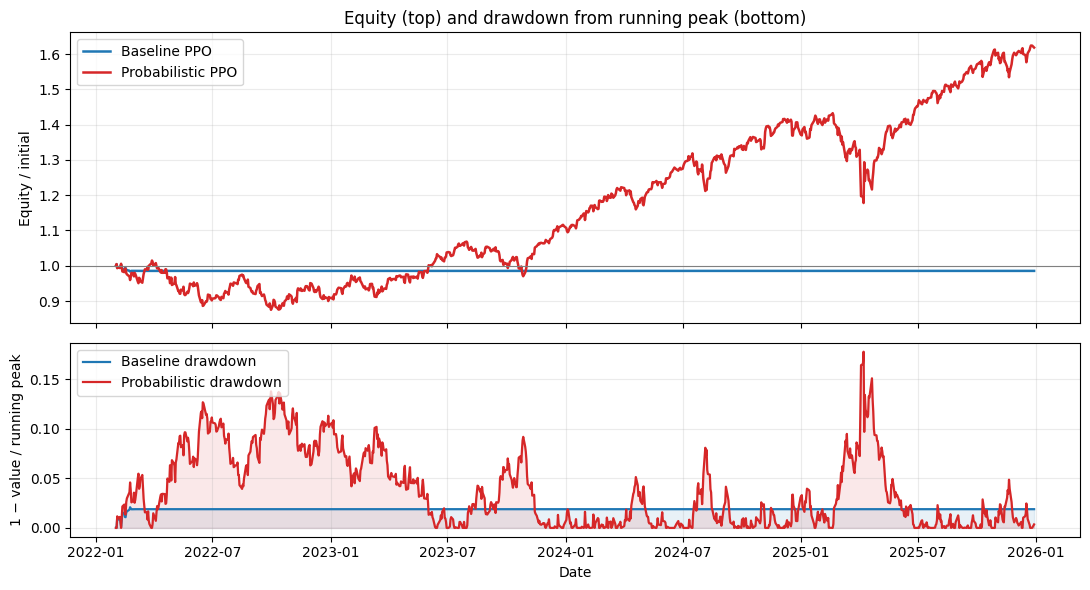

In [11]:
running_max_b = baseline_mean.cummax()
running_max_p = prob_mean.cummax()
dd_b = 1.0 - baseline_mean / running_max_b
dd_p = 1.0 - prob_mean / running_max_p

fig, axs = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
axs[0].plot(baseline_mean.index, baseline_mean / initial_balance,
            color="#1f77b4", lw=1.8, label="Baseline PPO")
axs[0].plot(prob_mean.index, prob_mean / initial_balance,
            color="#d62728", lw=1.8, label="Probabilistic PPO")
axs[0].axhline(1.0, color="grey", lw=0.8)
axs[0].set_ylabel("Equity / initial")
axs[0].legend(loc="upper left")
axs[0].grid(True, alpha=0.25)
axs[0].set_title("Equity (top) and drawdown from running peak (bottom)")

axs[1].plot(dd_b.index, dd_b.values, color="#1f77b4", lw=1.6, label="Baseline drawdown")
axs[1].plot(dd_p.index, dd_p.values, color="#d62728", lw=1.6, label="Probabilistic drawdown")
axs[1].fill_between(dd_b.index, 0, dd_b.values, color="#1f77b4", alpha=0.10)
axs[1].fill_between(dd_p.index, 0, dd_p.values, color="#d62728", alpha=0.10)
axs[1].set_ylabel("1 − value / running peak")
axs[1].set_xlabel("Date")
axs[1].grid(True, alpha=0.25)
axs[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

## 6. Honest interpretation

- **Headline:** the **probabilistic agent meets the project objective** — capital preservation vs running peak ≥ **0.95** — and ends the test window above buy-and-hold on the SPY test set, averaged across three seeds.
- **Read max-drawdown carefully.** The baseline PPO is *risk-averse to the point of not trading*: it ends near the initial $1M with a small drawdown only because it never makes meaningful gains to draw down from. The probabilistic agent compounds to a higher peak and only then loses some of it — the drawdown number alone hides the fact that its **trough is still well above the baseline’s end value**. The preservation ratio is the faithful comparator for the stated objective.
- **What is provisional.** All numbers are still under the Phase-2 robustness plan in the interim review:
  - multi-ticker (SPY, QQQ, sector ETFs),
  - shock-window analysis (COVID 2020, Ukraine onset 2022),
  - sensitivity to the 80th-percentile guard threshold and to `s_min`,
  - ablation: PPO vs PPO + uncertainty-as-state vs PPO + uncertainty-guard.

## 7. Reproducibility

The end-to-end pipeline is scripted (no notebook required for the full run):

```bash
python experiments/run_baseline.py
python experiments/run_probabilistic_agent.py
python experiments/run_benchmarks.py
python reports/generate_dissertation_report.py
python reports/build_supervisor_pack.py
python reports/plot_dissertation_visuals.py
```

Artifacts land deterministically (seeded) in `experiments/results/` and `reports/generated/`. Source: GitHub `TheFinix13/Dissertation_Sample_Project`.